# 01 - Exploratory Data Analysis (EDA)
First look at the Snappfood reviews: how big the data is, whether the labels are balanced,
how long the comments are, and which words show up most.

## 0. Setup
Connect Google Drive, where the CSV file is stored.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
DATA_PATH = "/content/drive/MyDrive/snappfood-sentiment/Snappfood - Sentiment Analysis.csv"

if os.path.exists(DATA_PATH):
    print("Data file found.")
else:
    print("Data file NOT found. Check the folder and file name in your Google Drive.")

Mounted at /content/drive
Data file found.


In [2]:
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

## 1. Load the raw data
The file is tab-separated. A few rows are broken, so we skip them.

In [3]:
raw = pd.read_csv(DATA_PATH, sep="\t", on_bad_lines="skip", engine="python")

print("shape:", raw.shape)
print("columns:", raw.columns.tolist())
raw.head()

shape: (70000, 3)
columns: ['comment', 'label', 'label_id']


,comment,label,label_id
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم ...,HAPPY,0
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,1
3,عالللی بود همه چه درست و به اندازه و کیفیت خوب، امیداورم همیشه کیفیتتون خوب باشه ما مشتری همیشگی بشیم,HAPPY,0
4,شیرینی وانیلی فقط یک مدل بود.,HAPPY,0


In [ ]:
# which values appear in the label column?
raw["label"].value_counts(dropna=False).head(10)

## 2. Minimal cleaning
- keep only rows labeled HAPPY or SAD
- drop empty comments
- drop comments that appear with **both** labels (we can't trust them)
- drop exact duplicates

Note: in the original file HAPPY = 0 and SAD = 1. We flip it so **positive = 1**, which is easier to read later.

In [4]:
LABEL_MAP = {"HAPPY": 1, "SAD": 0}

def clean_data(df):
    n0 = len(df)
    df = df[["comment", "label"]].copy()

    df["label"] = df["label"].astype(str).str.strip().str.upper()
    df = df[df["label"].isin(LABEL_MAP)]
    n1 = len(df)

    df = df.dropna(subset=["comment"])
    df["comment"] = df["comment"].astype(str).str.strip()
    df = df[df["comment"] != ""]
    n2 = len(df)

    conflict = df.groupby("comment")["label"].nunique()
    conflict = conflict[conflict > 1].index
    df = df[~df["comment"].isin(conflict)]
    n3 = len(df)

    df = df.drop_duplicates(subset="comment")
    df["sentiment"] = df["label"].map(LABEL_MAP)
    df = df.reset_index(drop=True)

    print(f"raw rows:                   {n0:,}")
    print(f"invalid label removed:      {n0 - n1:,}")
    print(f"empty comment removed:      {n1 - n2:,}")
    print(f"conflicting labels removed: {n2 - n3:,}")
    print(f"duplicates removed:         {n3 - len(df):,}")
    print(f"final rows:                 {len(df):,}")
    return df

df = clean_data(raw)
df.head()

raw rows:                   70,000
invalid label removed:      0
empty comment removed:      0
conflicting labels removed: 0
duplicates removed:         0
final rows:                 70,000


,comment,label,sentiment
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,0
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم ...,HAPPY,1
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,0
3,عالللی بود همه چه درست و به اندازه و کیفیت خوب، امیداورم همیشه کیفیتتون خوب باشه ما مشتری همیشگی بشیم,HAPPY,1
4,شیرینی وانیلی فقط یک مدل بود.,HAPPY,1


## 3. Label balance

label
SAD      35000
HAPPY    35000
Name: count, dtype: int64
label
SAD      0.5
HAPPY    0.5
Name: count, dtype: float64


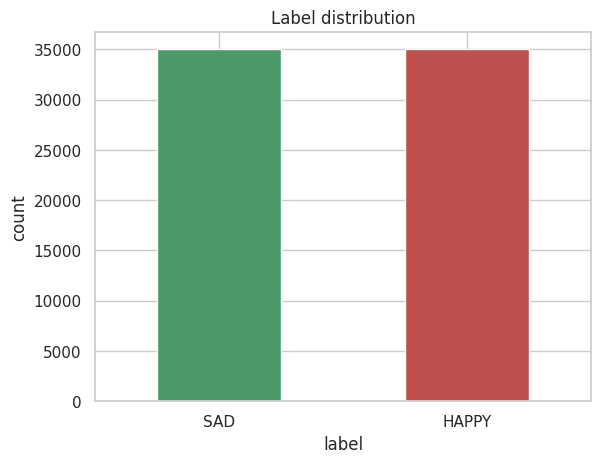

In [5]:
counts = df["label"].value_counts()
print(counts)
print((counts / len(df)).round(3))

ax = counts.plot(kind="bar", color=["#4C9A6A", "#C0504D"], rot=0)
ax.set_title("Label distribution")
ax.set_ylabel("count")
plt.show()

## 4. Comment length

In [6]:
df["n_words"] = df["comment"].str.split().str.len()
df["n_chars"] = df["comment"].str.len()

df.groupby("label")[["n_words", "n_chars"]].describe().T

label                 HAPPY           SAD
n_words count  35000.000000  35000.000000
        mean      16.054257     21.240114
        std       13.689816     17.294089
        min        3.000000      3.000000
        25%        7.000000     10.000000
        50%       12.000000     16.000000
        75%       20.000000     27.000000
        max      192.000000    361.000000
n_chars count  35000.000000  35000.000000
        mean      77.177571    102.358600
        std       66.522907     83.875780
        min       12.000000     11.000000
        25%       35.000000     46.000000
        50%       57.000000     78.000000
        75%       96.000000    131.000000
        max      924.000000   1700.000000

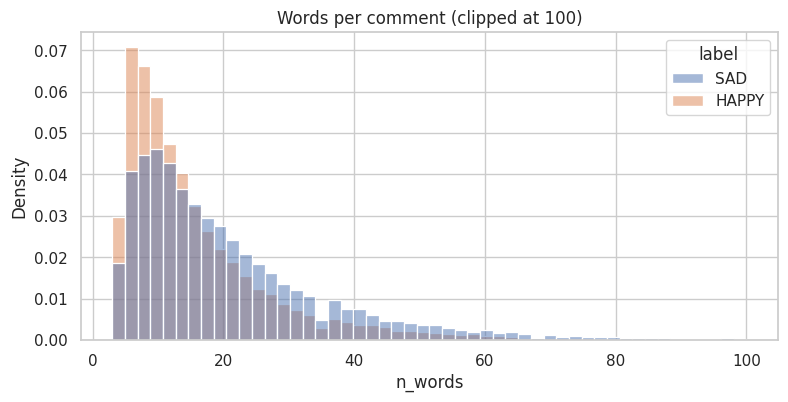

In [7]:
plt.figure(figsize=(9, 4))
sns.histplot(data=df[df["n_words"] <= 100], x="n_words", hue="label",
             bins=50, stat="density", common_norm=False)
plt.title("Words per comment (clipped at 100)")
plt.show()

In [8]:
# a quick look at the shortest and longest comments
print(df.nsmallest(5, "n_words")[["comment", "label"]])
print()
print(df.nlargest(3, "n_words")[["comment", "label"]])

                comment  label
12313    درصدش پنیر بود    SAD
38447    دقیقه دیر رسید  HAPPY
46322    ساعت معطلی چرا    SAD
48814     درصد کاهو بود    SAD
49254  شکلات میلکا نیست  HAPPY

                                                                                                                       comment  \
43115  اسنپ مثل همیشه عالی این همه راه رو سریع اومد داغ اورد ولی واقعا از رستوران ایتالیایی مثل شما بعیده عذاتون طعم خوبی ن...   
23053  متاسفانه اصلا خوب نبود اولا که کیکی که تحویل داده شد با عکس آن کمی تفاوت داشت مثلا در عکس برای تزیین از شکلات استفاد...   
16875  گفتم این دفعه دیگه حوصله نظر دادن ندارم ولی تو ذهنم گفتم شاید بی انصافی باشه، اولا ۱۰:۵۲ سفارش دادم و ۱۱:۱۵ غذا رسید...   

       label  
43115    SAD  
23053    SAD  
16875  HAPPY  


## 5. Most frequent words per label
No stopword removal yet, so words like «و» and «از» will be at the top.
That's exactly why we need preprocessing in the next notebook.

In [9]:
def simple_tokens(text):
    return re.findall(r"[\u0600-\u06FF\u200c]+", text)

top = {}
for lab in ["HAPPY", "SAD"]:
    c = Counter(t for txt in df.loc[df["label"] == lab, "comment"] for t in simple_tokens(txt))
    top[lab] = pd.Series([w for w, _ in c.most_common(25)])

pd.concat(top, axis=1)

,HAPPY,SAD
0,بود,بود
1,و,و
2,عالی,که
3,خیلی,به
4,به,از
5,خوب,غذا
6,از,هم
7,هم,خیلی
8,که,کیفیت
9,غذا,با


## 6. Key findings
- **Clean data:** all 70,000 rows are valid, with no empty, duplicate or conflicting comments. Near-duplicates (e.g. Arabic vs. Persian "ی") will be checked again after normalization.
- **Perfectly balanced:** exactly 35,000 HAPPY and 35,000 SAD reviews, so accuracy is a fair metric. Real-world reviews are probably not this balanced, which is a limitation.
- **Unhappy customers write more:** median length is 16 words for SAD vs. 12 for HAPPY. Very short reviews (3-10 words) are mostly positive.
- **Stopwords dominate:** words like «و», «از», «که» top both classes and carry no sentiment, so they must be removed.
- **Negation matters:** «خوب» (good) appears in the SAD list, likely from phrases like «خوب نبود» (wasn't good). So negation words must be kept during stopword removal, and bigrams should be used in modeling.
- **Early complaint signals:** «سرد» (cold) and «پیتزا» (pizza) appear only in the SAD list. We will explore them later with clustering.